In [1]:
import os
import sys
from pathlib import Path

def find_project_root(marker_files=('run_models.py', 'mujoco_physics.py')):
    current = Path.cwd().resolve()
    for _ in range(6):
        if all((current / m).exists() for m in marker_files):
            return current
        for child in current.iterdir():
            if child.is_dir() and all((child / m).exists() for m in marker_files):
                return child
        current = current.parent
    raise RuntimeError(f'Не могу найти корень проекта от {Path.cwd()}')

ROOT = find_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

import numpy as np
import torch
import matplotlib.pyplot as plt
import lib.utils as utils
from spiral_dataset import SpiralDataset

print('ROOT:', ROOT)

ROOT: D:\Skoltech\ML\Project\code\asa-ode


In [2]:
# ── КОНФИГ ────────────────────────────────────────────────────────────────
N_VIZ        = 4      # траекторий в каждой выборке
NOISE_WEIGHT = 0.03   # шум (0.0 = чистые данные)

device = torch.device('cpu')

# Зашумлённые данные
dataset_obj  = SpiralDataset(root='data', generate=True, noise_weight=NOISE_WEIGHT, device=device)
full_noisy   = dataset_obj.get_dataset()  # (10000, 200, 2)

# Чистые данные (для GT линии)
clean_obj    = SpiralDataset(root='data', generate=False, noise_weight=0.0, device=device)
full_clean   = clean_obj.get_dataset()

train_noisy, test_noisy = utils.split_train_test(full_noisy, train_fraq=0.8)
train_clean, test_clean = utils.split_train_test(full_clean, train_fraq=0.8)

T     = full_noisy.shape[1]   # 200
n_obs = T // 2                # 100
t     = np.linspace(0, 1, T)

print(f'Train: {train_noisy.shape}  |  Test: {test_noisy.shape}')

Train: torch.Size([8000, 200, 2])  |  Test: torch.Size([2000, 200, 2])


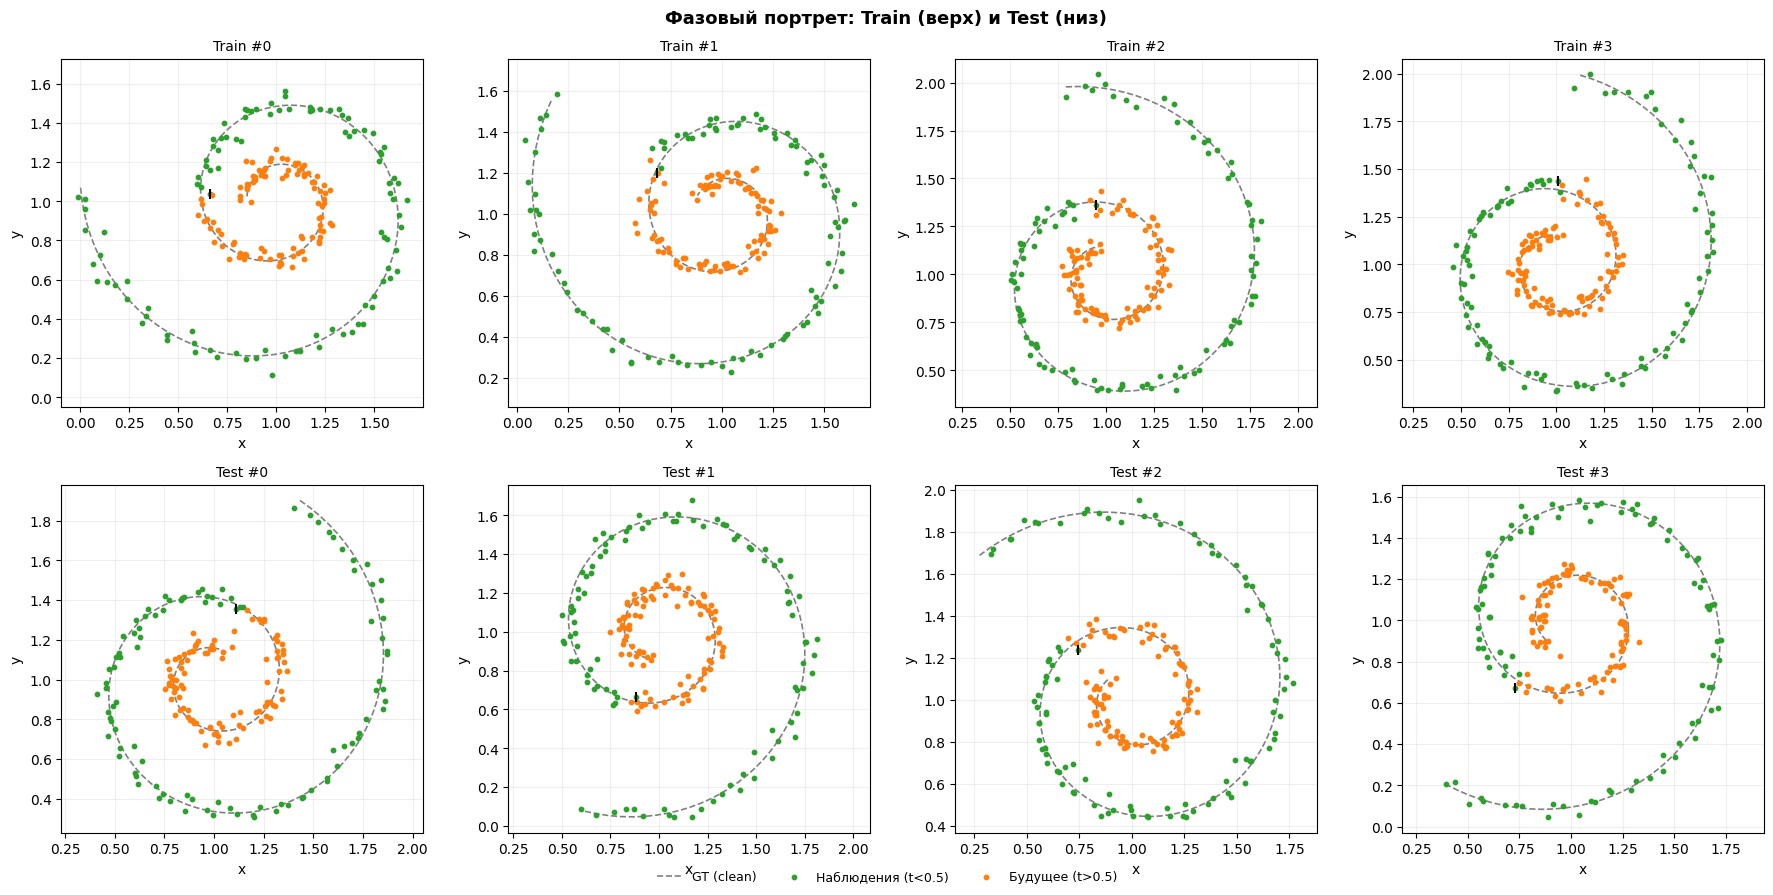

In [3]:
# ── Фазовый портрет: Train и Test рядом ───────────────────────────────────
fig, axes = plt.subplots(2, N_VIZ, figsize=(4.5 * N_VIZ, 9))

for col in range(N_VIZ):
    for row, (noisy, clean, split_label) in enumerate([
        (train_noisy, train_clean, 'Train'),
        (test_noisy,  test_clean,  'Test'),
    ]):
        ax  = axes[row][col]
        traj_noisy = noisy[col].numpy()   # (200, 2)
        traj_clean = clean[col].numpy()

        obs  = traj_noisy[:n_obs]   # наблюдаемая часть
        fut  = traj_noisy[n_obs:]   # будущая часть
        gt   = traj_clean           # чистая траектория

        # GT пунктир
        ax.plot(gt[:, 0], gt[:, 1], color='gray', lw=1.2, ls='--', zorder=1, label='GT (clean)')
        # Наблюдения — точки
        ax.scatter(obs[:, 0], obs[:, 1], color='tab:green', s=10, zorder=3, label='Наблюдения (t<0.5)')
        # Будущее — точки
        ax.scatter(fut[:, 0], fut[:, 1], color='tab:orange', s=10, zorder=3, label='Будущее (t>0.5)')
        # Граница
        ax.scatter(obs[-1, 0], obs[-1, 1], color='black', s=60, zorder=5, marker='|')

        ax.set_title(f'{split_label} #{col}', fontsize=10)
        ax.set_xlabel('x'); ax.set_ylabel('y')
        ax.axis('equal'); ax.grid(alpha=0.2)

handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncols=3, frameon=False, fontsize=9)
fig.suptitle('Фазовый портрет: Train (верх) и Test (низ)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('spiral_train_test_phase.png', dpi=150, bbox_inches='tight')
plt.show()

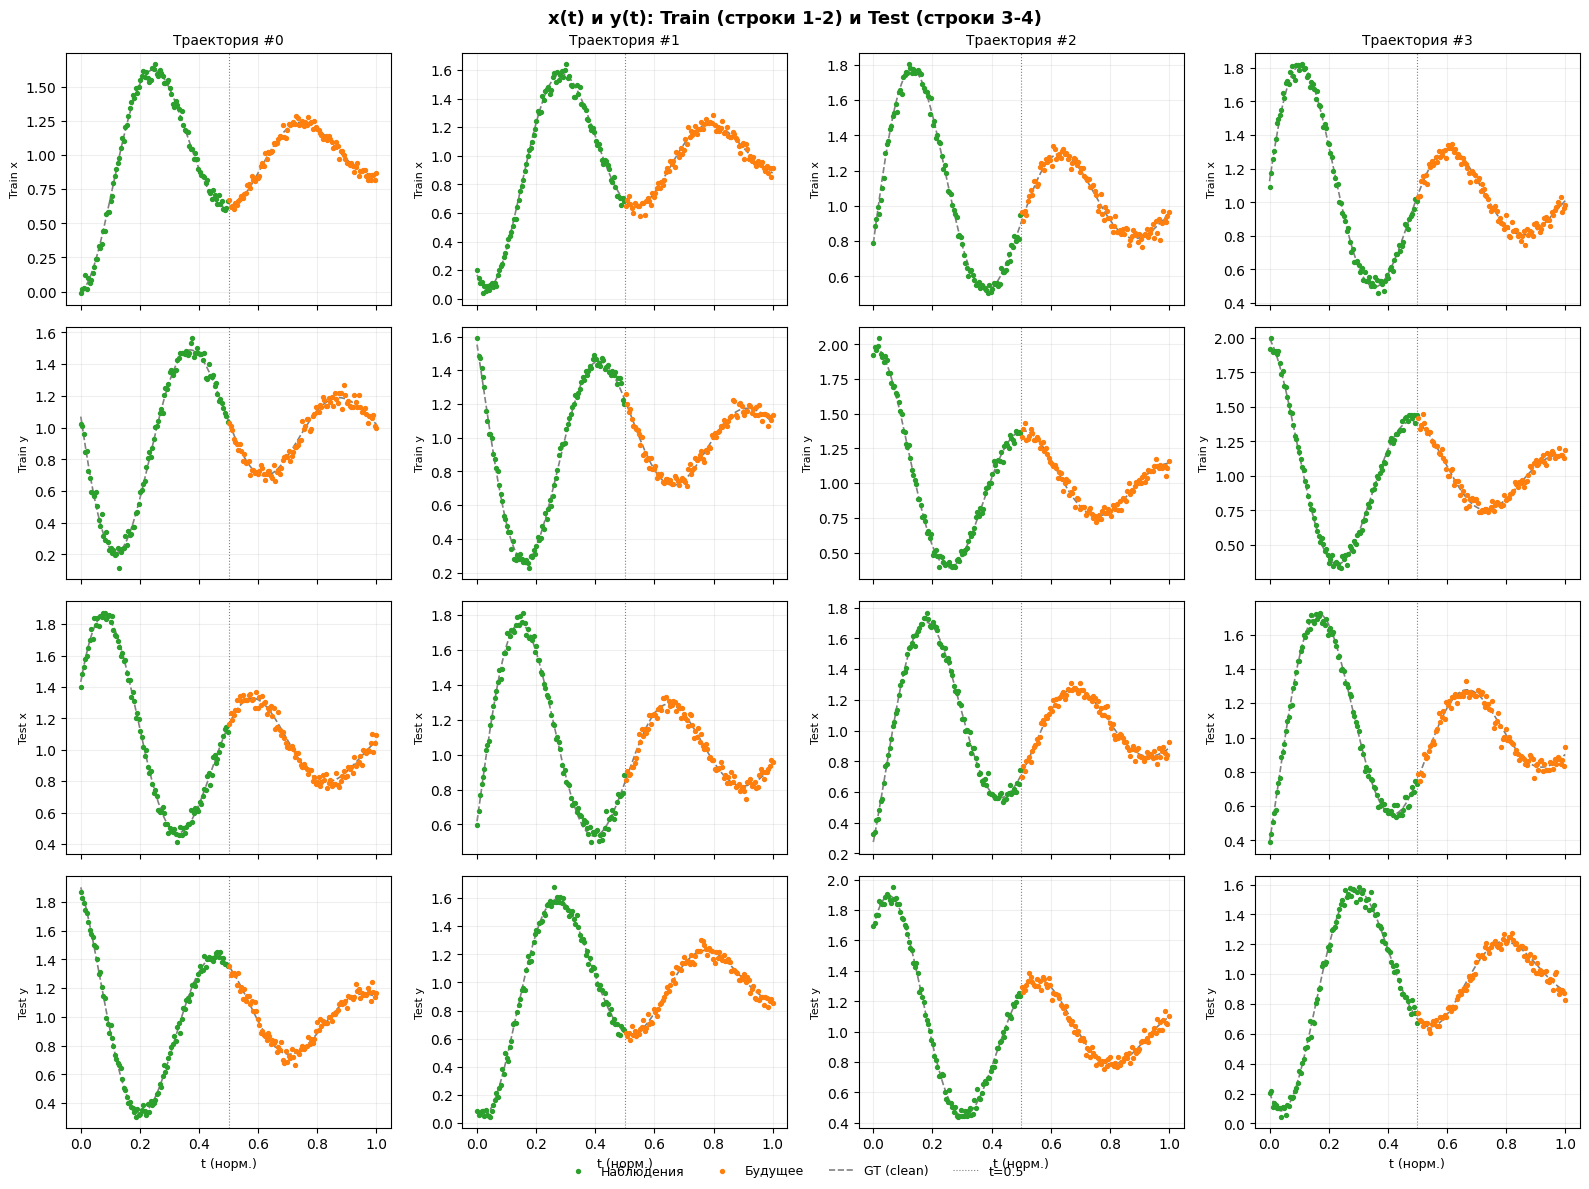

In [4]:
# ── x(t) и y(t) по времени: Train и Test рядом ────────────────────────────
fig, axes = plt.subplots(4, N_VIZ, figsize=(4 * N_VIZ, 12), sharex=True)

for col in range(N_VIZ):
    for row_offset, (noisy, clean, split_label) in enumerate([
        (train_noisy, train_clean, 'Train'),
        (test_noisy,  test_clean,  'Test'),
    ]):
        traj_noisy = noisy[col].numpy()
        traj_clean = clean[col].numpy()

        for dim, dname in enumerate(['x', 'y']):
            ax = axes[row_offset * 2 + dim][col]
            ax.scatter(t[:n_obs], traj_noisy[:n_obs, dim],
                       color='tab:green', s=8, zorder=3, label='Наблюдения')
            ax.scatter(t[n_obs:], traj_noisy[n_obs:, dim],
                       color='tab:orange', s=8, zorder=3, label='Будущее')
            ax.plot(t, traj_clean[:, dim],
                    color='gray', lw=1.2, ls='--', zorder=1, label='GT (clean)')
            ax.axvline(0.5, color='gray', lw=0.8, ls=':', label='t=0.5')
            ax.set_ylabel(f'{split_label} {dname}', fontsize=8)
            ax.grid(alpha=0.2)
            if row_offset == 0 and dim == 0:
                ax.set_title(f'Траектория #{col}', fontsize=10)

for col in range(N_VIZ):
    axes[-1][col].set_xlabel('t (норм.)', fontsize=9)

handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncols=4, frameon=False, fontsize=9)
fig.suptitle('x(t) и y(t): Train (строки 1-2) и Test (строки 3-4)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('spiral_train_test_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# ── Статистика по train и test ─────────────────────────────────────────────
for split_name, data in [('Train', train_noisy), ('Test', test_noisy)]:
    vals = data.numpy()
    print(f'{split_name}: n={len(vals)}  '
          f'x=[{vals[:,:,0].min():.3f}, {vals[:,:,0].max():.3f}]  '
          f'y=[{vals[:,:,1].min():.3f}, {vals[:,:,1].max():.3f}]  '
          f'std_x={vals[:,:,0].std():.3f}  std_y={vals[:,:,1].std():.3f}')

Train: n=8000  x=[-0.077, 2.077]  y=[-0.084, 2.098]  std_x=0.360  std_y=0.360
Test: n=2000  x=[-0.066, 2.090]  y=[-0.068, 2.076]  std_x=0.360  std_y=0.360


In [11]:
# ── КОНФИГ: укажите ID эксперимента ───────────────────────────────────────
EXPERIMENT_ID  = 48280   # int, например 42317  (None = последний checkpoint в папке)
CKPT_DIR       = ROOT / 'experiments'   # абсолютный путь
N_VIZ          = 4      # сколько траекторий показывать на графиках
N_TRAJ_SAMPLES = 10      # сколько сэмплов из латентного пространства

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if EXPERIMENT_ID is None:
    ckpts = sorted(CKPT_DIR.glob('experiment_*.ckpt'), key=lambda p: p.stat().st_mtime)
    if not ckpts:
        raise FileNotFoundError(f'Нет checkpoint-ов в {CKPT_DIR}/')
    ckpt_path = ckpts[-1].resolve()
else:
    ckpt_path = (CKPT_DIR / f'experiment_{EXPERIMENT_ID}.ckpt').resolve()

print('Загружаем:', ckpt_path)

Загружаем: D:\Skoltech\ML\Project\code\asa-ode\experiments\experiment_48280.ckpt


In [12]:
# ── Загрузка модели из checkpoint ─────────────────────────────────────────
import argparse
import torch.nn as nn
from torch.distributions.normal import Normal
from lib.create_latent_ode_model import create_LatentODE_model
from lib.rnn_baselines import RNN_VAE, Classic_RNN
from lib.latent_ode import LatentODE
import lib.utils as utils

torch.serialization.add_safe_globals([argparse.Namespace])
ckpt = torch.load(str(ckpt_path), map_location=device, weights_only=False)
args = ckpt['args']

print('Тип модели:',
      'LatentODE'   if getattr(args, 'latent_ode', False) else
      'RNN-VAE'     if getattr(args, 'rnn_vae',    False) else
      'Classic-RNN' if getattr(args, 'classic_rnn',False) else 'Unknown')
print('Датасет:', args.dataset, ' | Latents:', args.latents)

# Добавляем атрибуты, которых может не быть в старых чекпойнтах
for attr, default in [('input_decay', False), ('rnn_cell', 'gru'),
                       ('z0_encoder', 'odernn'), ('linear_classif', False)]:
    if not hasattr(args, attr):
        setattr(args, attr, default)

input_dim = 2  # spiral: x, y
obsrv_std = torch.Tensor([0.01]).to(device)
z0_prior  = Normal(torch.Tensor([0.0]).to(device), torch.Tensor([1.0]).to(device))

if getattr(args, 'rnn_vae', False):
    model = RNN_VAE(
        input_dim, args.latents, device=device,
        rec_dims=args.rec_dims, concat_mask=True,
        obsrv_std=obsrv_std, z0_prior=z0_prior,
        use_binary_classif=False, classif_per_tp=False,
        linear_classifier=args.linear_classif,
        n_units=args.units, input_space_decay=args.input_decay,
        cell=args.rnn_cell, n_labels=1,
        train_classif_w_reconstr=False
    ).to(device)
elif getattr(args, 'latent_ode', False):
    model = create_LatentODE_model(args, input_dim, z0_prior, obsrv_std, device)
else:
    raise Exception("Неизвестный тип модели — проверь args")

model.load_state_dict(ckpt['state_dict'])
model.to(device).eval()
print('Модель загружена!')


Тип модели: LatentODE
Датасет: spiral  | Latents: 15
Модель загружена!


In [13]:
# ── Инференс: предсказания для train и test ────────────────────────────────
T_full = train_noisy.shape[1]   # 200
n_obs  = T_full // 2            # 100

time_steps    = torch.arange(T_full, dtype=torch.float32).to(device) / T_full
observed_tp   = time_steps[:n_obs]
tp_to_predict = time_steps[n_obs:]

def predict(data, n):
    batch = data[:n].to(device)
    obs   = batch[:, :n_obs, :]
    mask  = torch.ones_like(obs)
    with torch.no_grad():
        if isinstance(model, LatentODE):
            pred_x, _ = model.get_reconstruction(
                time_steps_to_predict=tp_to_predict, truth=obs,
                truth_time_steps=observed_tp, mask=mask,
                n_traj_samples=N_TRAJ_SAMPLES, mode='extrap')
        else:
            pred_x, _ = model.get_reconstruction(
                time_steps_to_predict=tp_to_predict, data=obs,
                truth_time_steps=observed_tp, mask=mask,
                n_traj_samples=N_TRAJ_SAMPLES, mode='extrap')
    return pred_x.mean(dim=0).cpu(), pred_x.std(dim=0).cpu()

train_pred_mean, train_pred_std = predict(train_noisy, N_VIZ)
test_pred_mean,  test_pred_std  = predict(test_noisy,  N_VIZ)

print(f'train_pred_mean shape : {train_pred_mean.shape}')
print(f'has NaN               : {torch.isnan(train_pred_mean).any()}')

train_mse = torch.mean((train_pred_mean - train_noisy[:N_VIZ, n_obs:, :].cpu()) ** 2)
test_mse  = torch.mean((test_pred_mean  - test_noisy[:N_VIZ,  n_obs:, :].cpu()) ** 2)
print(f'Train MSE: {train_mse:.6f} | Test MSE: {test_mse:.6f}')

train_pred_mean shape : torch.Size([4, 100, 2])
has NaN               : False
Train MSE: 0.109222 | Test MSE: 0.049672


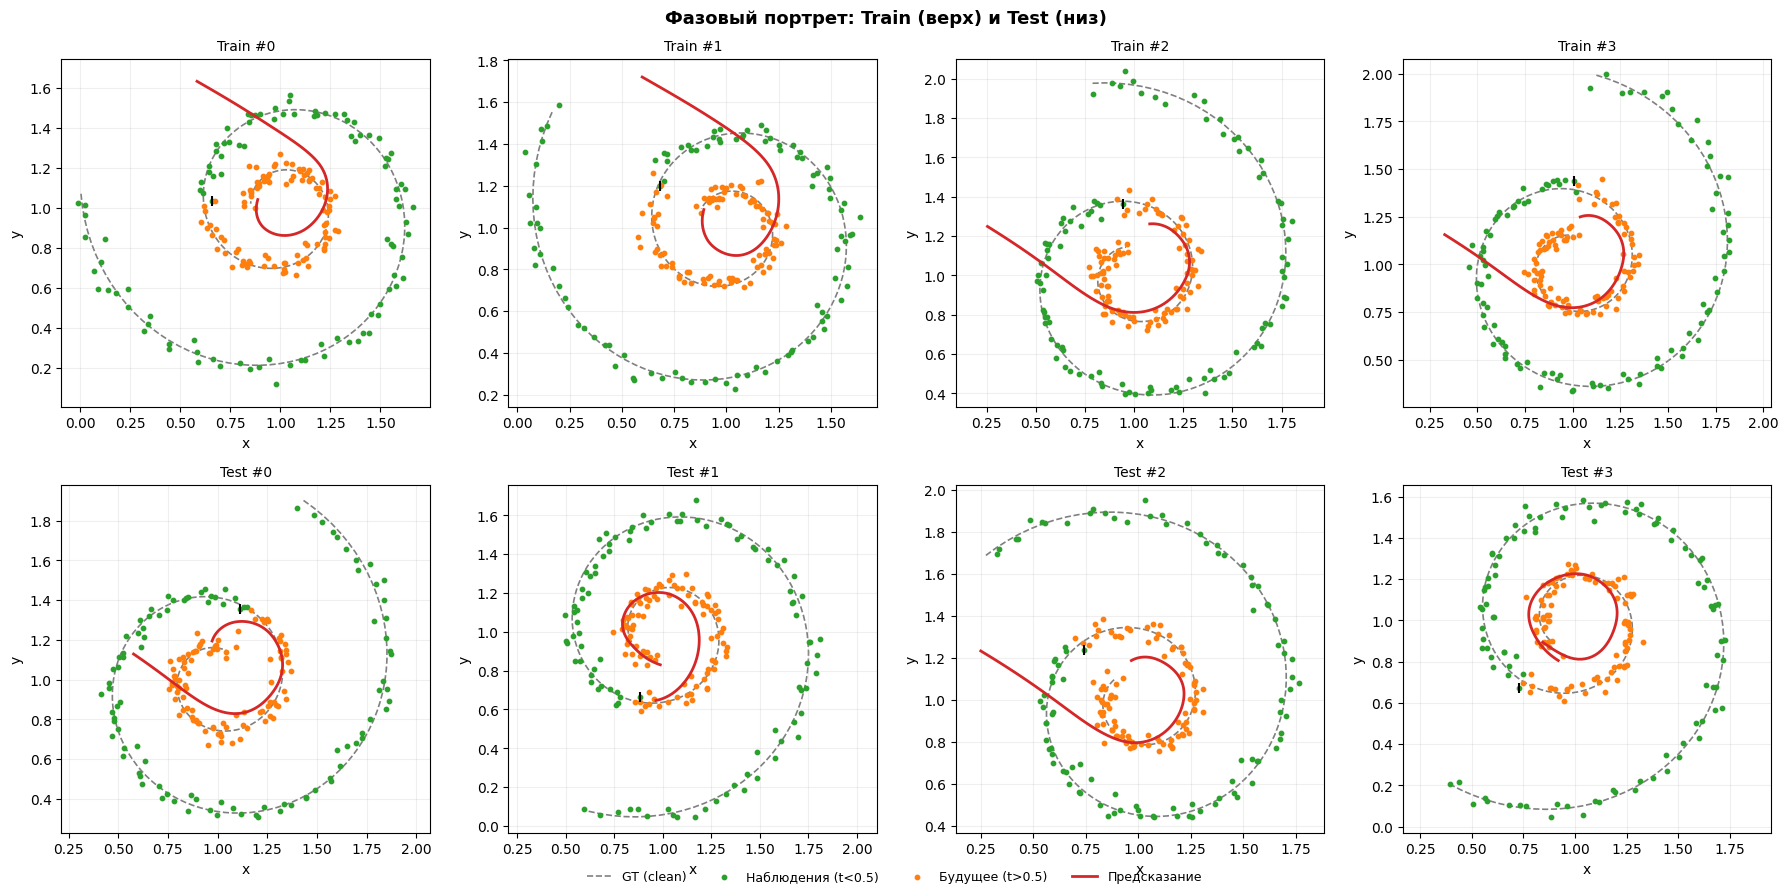

In [14]:
# ── Фазовый портрет: Train (верх) и Test (низ) с предсказаниями ───────────
t_obs_np  = observed_tp.cpu().numpy()
t_pred_np = tp_to_predict.cpu().numpy()

fig, axes = plt.subplots(2, N_VIZ, figsize=(4.5 * N_VIZ, 9))

for col in range(N_VIZ):
    for row, (noisy, clean, pred_mean, split_label) in enumerate([
        (train_noisy, train_clean, train_pred_mean, 'Train'),
        (test_noisy,  test_clean,  test_pred_mean,  'Test'),
    ]):
        ax = axes[row][col]
        obs_np   = noisy[col, :n_obs, :].numpy()
        fut_np   = noisy[col, n_obs:, :].numpy()
        gt_np    = clean[col].numpy()
        pred_np  = pred_mean[col].numpy()

        ax.plot(gt_np[:, 0],   gt_np[:, 1],
                color='gray', lw=1.2, ls='--', zorder=1, label='GT (clean)')
        ax.scatter(obs_np[:, 0], obs_np[:, 1],
                   color='tab:green', s=10, zorder=3, label='Наблюдения (t<0.5)')
        ax.scatter(fut_np[:, 0], fut_np[:, 1],
                   color='tab:orange', s=10, zorder=3, label='Будущее (t>0.5)')
        ax.plot(pred_np[:, 0], pred_np[:, 1],
                color='tab:red', lw=2.0, zorder=4, label='Предсказание')
        ax.scatter(obs_np[-1, 0], obs_np[-1, 1],
                   color='black', s=60, zorder=5, marker='|')

        ax.set_title(f'{split_label} #{col}', fontsize=10)
        ax.set_xlabel('x'); ax.set_ylabel('y')
        ax.axis('equal'); ax.grid(alpha=0.2)

handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncols=4, frameon=False, fontsize=9)
fig.suptitle('Фазовый портрет: Train (верх) и Test (низ)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('spiral_train_test_phase_pred.png', dpi=150, bbox_inches='tight')
plt.show()


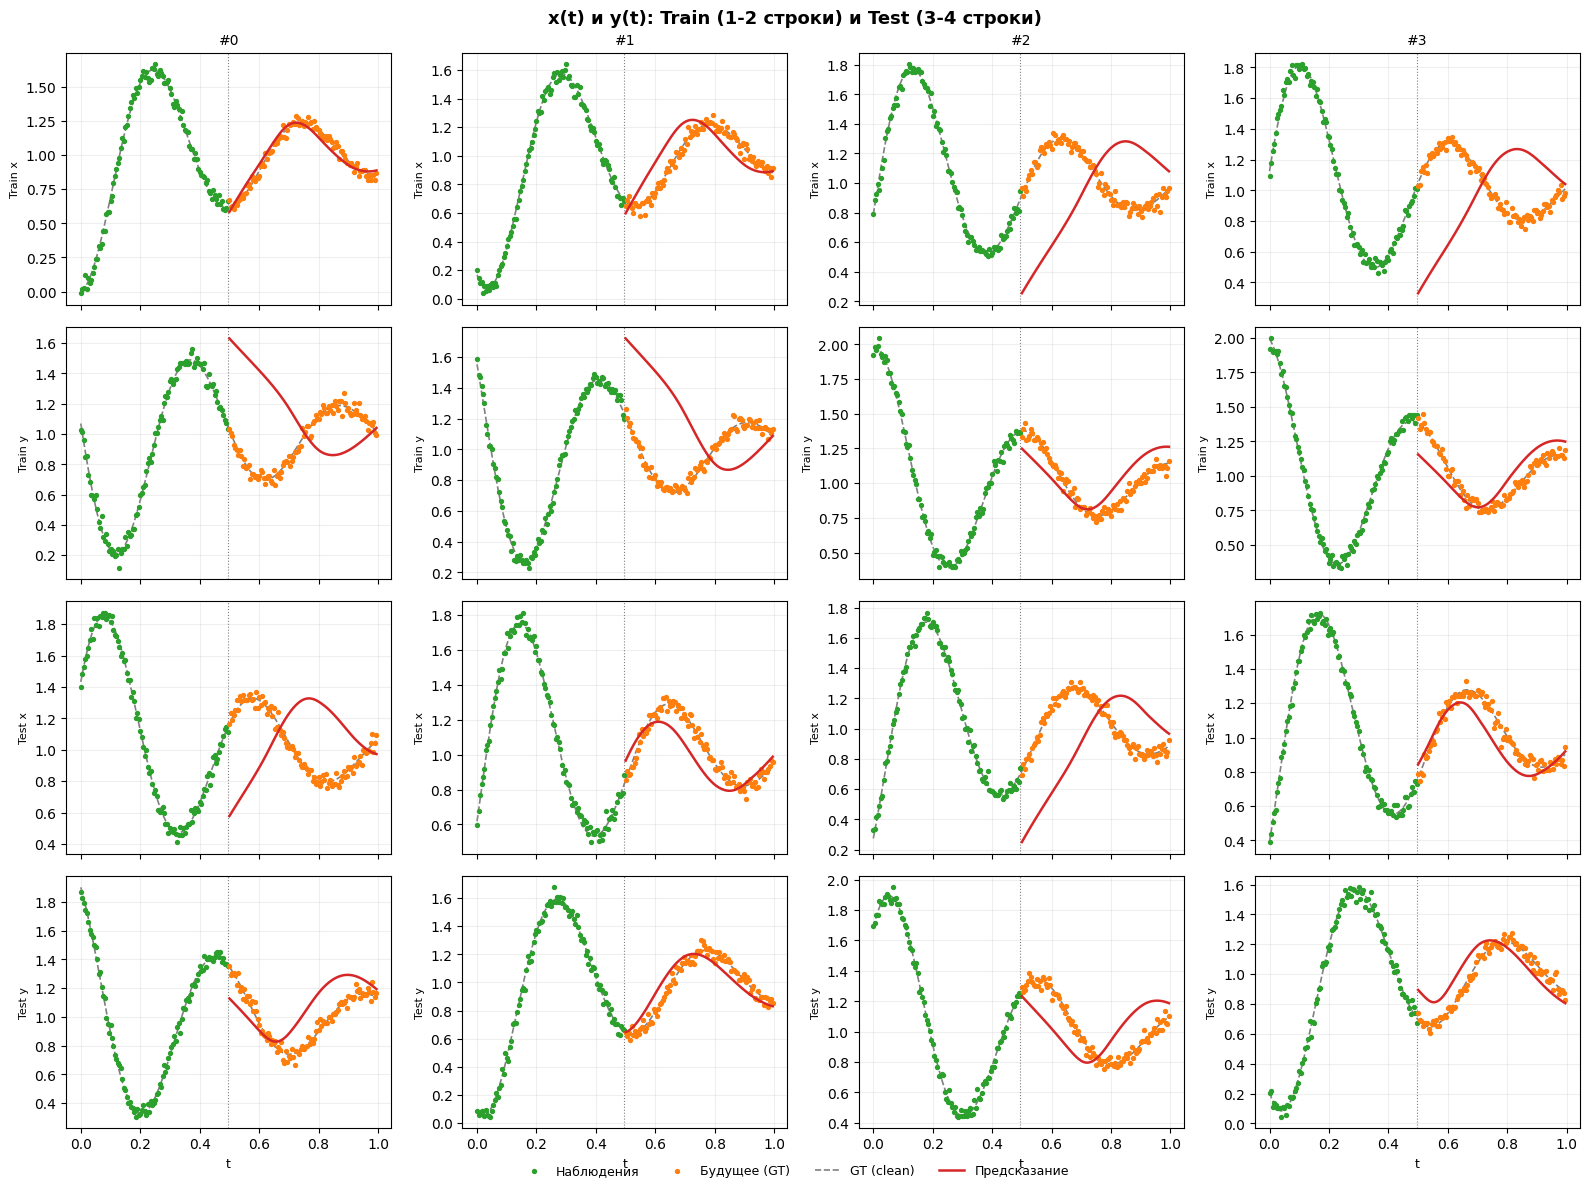

In [15]:
# ── x(t) и y(t) по времени с предсказаниями ───────────────────────────────
fig, axes = plt.subplots(4, N_VIZ, figsize=(4 * N_VIZ, 12), sharex=True)

for col in range(N_VIZ):
    for row_offset, (noisy, clean, pred_mean, split_label) in enumerate([
        (train_noisy, train_clean, train_pred_mean, 'Train'),
        (test_noisy,  test_clean,  test_pred_mean,  'Test'),
    ]):
        obs_np  = noisy[col, :n_obs, :].numpy()
        fut_np  = noisy[col, n_obs:, :].numpy()
        gt_np   = clean[col].numpy()
        pred_np = pred_mean[col].numpy()

        for dim, dname in enumerate(['x', 'y']):
            ax = axes[row_offset * 2 + dim][col]
            ax.scatter(t_obs_np,  obs_np[:, dim],
                       color='tab:green', s=8, zorder=3, label='Наблюдения')
            ax.scatter(t_pred_np, fut_np[:, dim],
                       color='tab:orange', s=8, zorder=3, label='Будущее (GT)')
            ax.plot(np.concatenate([t_obs_np, t_pred_np]),
                    gt_np[:, dim],
                    color='gray', lw=1.2, ls='--', zorder=1, label='GT (clean)')
            ax.plot(t_pred_np, pred_np[:, dim],
                    color='tab:red', lw=1.8, zorder=4, label='Предсказание')
            ax.axvline(t_obs_np[-1], color='gray', lw=0.8, ls=':')
            ax.set_ylabel(f'{split_label} {dname}', fontsize=8)
            ax.grid(alpha=0.2)
            if row_offset == 0 and dim == 0:
                ax.set_title(f'#{col}', fontsize=10)

for col in range(N_VIZ):
    axes[-1][col].set_xlabel('t', fontsize=9)

handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncols=4, frameon=False, fontsize=9)
fig.suptitle('x(t) и y(t): Train (1-2 строки) и Test (3-4 строки)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('spiral_train_test_timeseries_pred.png', dpi=150, bbox_inches='tight')
plt.show()
